In [30]:
import cv2
import numpy as np

img = cv2.imread("/content/images.jpg", cv2.IMREAD_GRAYSCALE)
if img is None:
  raise FileNotFoundError("Image not found.")

img_large = img.astype(np.int64)
img_large

array([[151, 115,  42, ..., 135, 152, 122],
       [ 69, 130,  44, ..., 135,  70, 165],
       [ 44,  56, 105, ...,  12,   0, 105],
       ...,
       [140, 141, 144, ...,  84, 106,  93],
       [149, 145, 143, ..., 103,  98, 103],
       [149, 146, 143, ..., 104,  97, 101]])

In [31]:
if img_large is None:
  raise FileNotFoundError("Typecasted Image not found.")

n = len(img_large)
m = len(img_large[0])

total = 0
for i in range(0,n):
  for j in range(0,m):
    total = total + img_large[i][j]

threshold = total / (n*m)
print("Threshold value is: ", threshold)

Threshold value is:  138.51337301018214


In [41]:
import copy

binary_img = copy.deepcopy(img_large)
for i in range(0,n):
  for j in range(0,m):
    if binary_img[i][j] >= threshold:
      binary_img[i][j] = 1
    else:
      binary_img[i][j] = 0

print(binary_img)

[[1 0 0 ... 0 1 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 ...
 [1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]]


Need to scale individual values to either be 0 or 255 because our eyes can't see difference between 0 and 1

image was coming completely black while array was correct

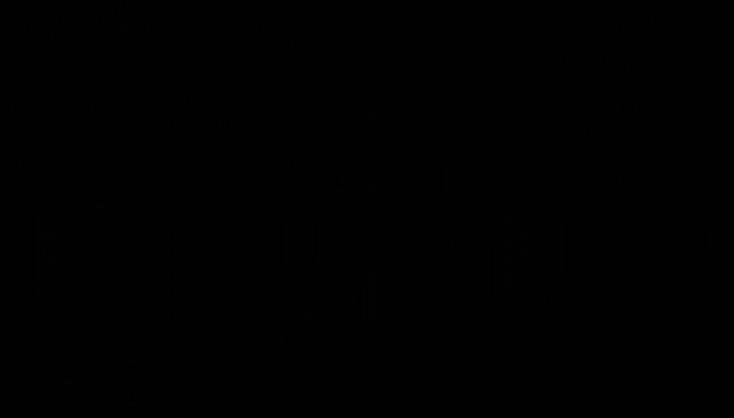

In [44]:
from google.colab.patches import cv2_imshow

cv2_imshow(binary_img) #only working when setting 0 or 255 with imshow

to showcase with 0 or 1 wali matrix, use matplotlib

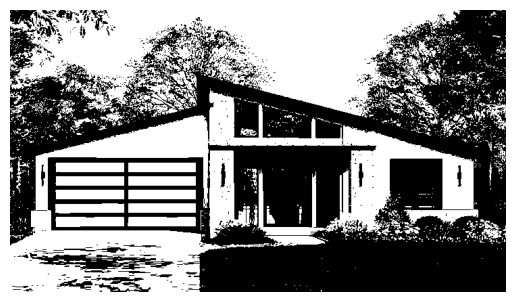

In [43]:
import matplotlib.pyplot as plt

plt.imshow(binary_img, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.show()

### Custom threshold input
input() always returns a string in python

Must manually convert it using type casting if you need to perform calculations.
- For integers (whole numbers): Wrap input() inside int().
- For floats (decimal numbers): Wrap input() inside float().

Enter custom threshold value: 190
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


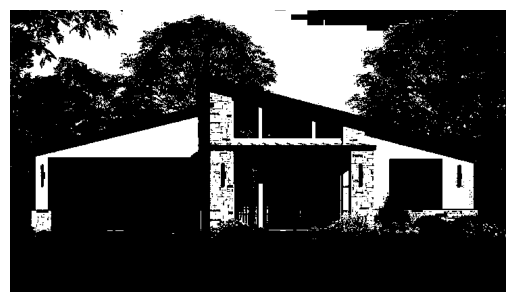

In [59]:
import copy
import matplotlib.pyplot as plt

threshold_cust = int(input("Enter custom threshold value: "))
if (threshold_cust < 0 or threshold_cust > 255):
  raise ValueError("Enter Threshold_value between 0 and 255")

binary_img_cust = copy.deepcopy(img_large)
for i in range(0,n):
  for j in range(0,m):
    if binary_img_cust[i][j] >= threshold_cust:
      binary_img_cust[i][j] = 1
    else:
      binary_img_cust[i][j] = 0

print(binary_img_cust)

plt.imshow(binary_img_cust, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.show()